## Download External dataset - Personal Income

In [2]:
# Download the income dataset from the website
import requests

specific_data_url = "https://www.abs.gov.au/statistics/labour/earnings-and-working-conditions/personal-income-australia/2015-16-2019-20/6524055002_DO001.xlsx"
output_path = '../../data/landing/external_data/Income.csv'

headers = {
     'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36'
}
response = requests.get(specific_data_url, headers=headers)

with open(output_path, 'wb') as out_file:
    out_file.write(response.content)

In [3]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import numpy as np

## Preprocessing

In [4]:

Income_file = pd.ExcelFile('../../data/landing/external_data/Income.csv')

# list the name of each sheets in csv file
sheet_list=Income_file.sheet_names
sheet_list

['Contents', 'Table 1.1', 'Table 1.2', 'Table 1.3', 'Table 1.4', 'Table 1.5']

In [5]:
# Read the excel file and drop the rows which are not required 
read_income =pd.read_excel('../../data/landing/external_data/Income.csv',sheet_name = ['Table 1.4'],header=None)['Table 1.4']
read_income=read_income.drop(range(6))
# 15-19

# Save the new dataset as a tempory income file
read_income.to_csv('../../data/raw/external_data/temp_income.csv')
read_income

,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
6,SA2,SA2 NAME,2015-16,2016-17,2017-18,2018-19,2019-20,2015-16,2016-17,2017-18,...,2015-16,2016-17,2017-18,2018-19,2019-20,2015-16,2016-17,2017-18,2018-19,2019-20
7,Australia,NaN,13358252,13678024,14069082,14425037,14619595,42,42,42,...,47692,48360,49805,51389,52338,61975,62594,64246,65953,67236
8,New South Wales,NaN,4191542,4344997,4466941,4569650,4614940,42,42,42,...,48085,48700,50153,51818,52849,64493,65196,67200,68816,70123
9,101021007,Braidwood,2153,2262,2315,2361,2426,50,50,51,...,39716,41288,42003,41593,44246,51074,51090,51594,51149,61745
10,101021008,Karabar,4937,4988,5059,5100,5128,42,42,42,...,55870,57880,59295,61777,62946,61093,62535,63790,66335,67345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2302,801111140,ACT - South West,289,347,364,355,354,39,39,39,...,62592,55384,61096,64227,68987,72858,70503,67445,73435,77301
2303,801111141,Namadgi,np,21,19,18,11,np,34,28,...,np,49981,58498,40479,32923,np,57309,56357,39278,37660
2304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2305,Totals may not align with the sum of their com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Extract the header of the income dataframe
income_header =  list(read_income.iloc[0])
income_header
# Header of the income dataset 
read_income = read_income[1:]

# Make the header become the new header 
read_income.columns = income_header

In [7]:
read_income

,SA2,SA2 NAME,2015-16,2016-17,2017-18,2018-19,2019-20,2015-16,2016-17,2017-18,...,2015-16,2016-17,2017-18,2018-19,2019-20,2015-16,2016-17,2017-18,2018-19,2019-20
7,Australia,NaN,13358252,13678024,14069082,14425037,14619595,42,42,42,...,47692,48360,49805,51389,52338,61975,62594,64246,65953,67236
8,New South Wales,NaN,4191542,4344997,4466941,4569650,4614940,42,42,42,...,48085,48700,50153,51818,52849,64493,65196,67200,68816,70123
9,101021007,Braidwood,2153,2262,2315,2361,2426,50,50,51,...,39716,41288,42003,41593,44246,51074,51090,51594,51149,61745
10,101021008,Karabar,4937,4988,5059,5100,5128,42,42,42,...,55870,57880,59295,61777,62946,61093,62535,63790,66335,67345
11,101021009,Queanbeyan,6419,6486,6595,6697,6778,39,39,39,...,54999,55376,57848,60119,61724,60764,60958,62863,65874,67276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2302,801111140,ACT - South West,289,347,364,355,354,39,39,39,...,62592,55384,61096,64227,68987,72858,70503,67445,73435,77301
2303,801111141,Namadgi,np,21,19,18,11,np,34,28,...,np,49981,58498,40479,32923,np,57309,56357,39278,37660
2304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2305,Totals may not align with the sum of their com...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Find the index when the sa2 is victoria and queensland
index_victoria= read_income.index[read_income['SA2'] == 'Victoria'].tolist()[0]
index_queensland= read_income.index[read_income['SA2'] == 'Queensland'].tolist()[0]


In [9]:
# Extract the income dataset in victoria state
victoria_income = read_income.iloc[index_victoria-6:index_queensland-7]
victoria_income.to_csv('../../data/raw/external_data/vic_income.csv')


In [10]:
# Extract the columns which is the number of earners each year from 2015 to 2019 as a dataframe
person = victoria_income.iloc[:,:7]
# Check if there is any null value in the dataframe 
person.isna().sum()
number_of_person =  victoria_income.iloc[:,:7]
number_of_person.isna().sum()
victoria_income.iloc[:,:2].isna().sum()
victoria_income.iloc[:, 12:17].isna().sum()
pd.concat([victoria_income.iloc[:,:2], victoria_income.iloc[:, 12:17]], axis=1)
pd.concat([victoria_income.iloc[:,:2], victoria_income.iloc[:, 12:17]], axis=1).drop(columns= ['SA2','SA2 NAME']).apply(pd.to_numeric, errors='coerce').isna().sum()


2015-16    6
2016-17    1
2017-18    1
2018-19    1
2019-20    2
dtype: int64

In [11]:
# Extract the 2015-2019 number of earners
number_of_person =  victoria_income.iloc[:,:7]

# Extract the columns of sa2 code and sa2 name
sa2_income = victoria_income.iloc[:,:2]

# Extract the total income from 2015-2019
sum_income = victoria_income.iloc[:, 12:17]

# Concatenate the sa2， sa2 name and the total income  into one dataframe
sa2_combine_sum_income = pd.concat([sa2_income, sum_income], axis=1)

# Drop the column of sa2， sa2 name, and turn into numeric data type
sa2_combine_sum_income= sa2_combine_sum_income.drop(columns= ['SA2','SA2 NAME']).apply(pd.to_numeric, errors='coerce')

# Drop the column of sa2， sa2 name, turn into numeric data type, and replace the null value into 0
number_of_person= number_of_person.drop(columns= ['SA2','SA2 NAME']).apply(pd.to_numeric, errors='coerce').replace(np.nan,0)
number_of_person.to_csv('../../data/raw/external_data/test_income.csv')

In [12]:
sa2_combine_sum_income

,2015-16,2016-17,2017-18,2018-19,2019-20
586,387942309.0,427625802.0,470977733.0,508645842.0,570048455.0
587,538382955.0,537056735.0,566382314.0,591465895.0,601074382.0
588,684128661.0,722652289.0,798508331.0,820866354.0,850335030.0
589,531985105.0,567584113.0,602910502.0,646001740.0,673553118.0
590,233227993.0,247116022.0,258264399.0,268782250.0,274481150.0
...,...,...,...,...,...
1043,93845375.0,102406124.0,102803242.0,109617595.0,114551687.0
1044,180270013.0,190473842.0,200279038.0,226791976.0,240054829.0
1045,281819262.0,296352511.0,300242872.0,325059577.0,344771899.0
1046,628892305.0,661227333.0,774560293.0,738088967.0,778973821.0


In [13]:
# calculate the personal income in each year regionally
new_dataframe = pd.DataFrame()

for i in range(sa2_combine_sum_income.shape[1]):
    col = sa2_combine_sum_income.columns[i]
    
    new_col = sa2_combine_sum_income[col] / number_of_person[col].replace(0, np.nan)
    new_dataframe[col] = new_col.fillna(0)
new_dataframe.to_csv('../../data/raw/external_data/personal_income.csv', index=False)

In [14]:
new_dataframe

,2015-16,2016-17,2017-18,2018-19,2019-20
586,57746.696785,60026.081134,62315.127415,63668.274127,65787.473168
587,72754.453378,71895.145248,74671.366381,77875.693878,78571.814641
588,54660.327661,56067.366669,59786.487796,60366.697603,62072.781225
589,46143.213201,47676.111970,49041.036441,50778.316302,52326.997980
590,58292.425144,60008.747450,61564.815018,63257.766533,64386.851982
...,...,...,...,...,...
1043,42425.576401,44235.906695,44755.438398,46448.133475,47949.638761
1044,47031.049570,49103.852024,50652.260496,55572.647880,58664.425464
1045,50306.901464,51459.022573,52080.290026,55546.749316,58003.347746
1046,50938.952292,52089.753663,59811.605637,56098.576195,58420.115569


In [15]:
# Calculate the growth rate of personal income annually
new_personal_income = pd.DataFrame()

for i in range(new_dataframe.shape[1] - 1):

    column_name = f'growth_rate_{new_dataframe.columns[i+1]}-{new_dataframe.columns[i]}'
    growth_rate = (new_dataframe[new_dataframe.columns[i+1]] - new_dataframe[new_dataframe.columns[i]]) / new_dataframe[new_dataframe.columns[i]]
    new_personal_income[column_name] = growth_rate
new_personal_income=new_personal_income.replace(np.nan,0).replace([np.inf, -np.inf], 0)


In [16]:
new_personal_income

,growth_rate_2016-17-2015-16,growth_rate_2017-18-2016-17,growth_rate_2018-19-2017-18,growth_rate_2019-20-2018-19
586,0.039472,0.038134,0.021715,0.033285
587,-0.011811,0.038615,0.042912,0.008939
588,0.025742,0.066333,0.009705,0.028262
589,0.033220,0.028629,0.035425,0.030499
590,0.029443,0.025931,0.027499,0.017849
...,...,...,...,...
1043,0.042671,0.011745,0.037821,0.032326
1044,0.044073,0.031533,0.097141,0.055635
1045,0.022902,0.012073,0.066560,0.044226
1046,0.022592,0.148241,-0.062079,0.041383


In [17]:
# Calculate the average annual personal income growth rate
new_personal_income['average_annual_income_growth_rate(%)'] = (new_personal_income[new_personal_income.columns[0]] + new_personal_income[new_personal_income.columns[1]] + new_personal_income[new_personal_income.columns[2]]+new_personal_income[new_personal_income.columns[3]])/4
new_personal_income_2 =  new_personal_income[['average_annual_income_growth_rate(%)']].reset_index(drop=True)
# Initialised the index 
new_dataframe= new_dataframe.reset_index(drop=True) 
# Combine the personal income growth rate of each year and average annual personal income rate
new_personal_income_combine =  pd.concat([new_dataframe, new_personal_income_2],axis=1)

#  Use the average annual personal income rate to find the growth rate in 2020-2021, 2021-2022
new_personal_income_combine['2020-21'] =  new_personal_income_combine['2019-20'] * (1 + new_personal_income_combine['average_annual_income_growth_rate(%)'])
new_personal_income_combine['2021-22'] =  new_personal_income_combine['2020-21'] * (1 + new_personal_income_combine['average_annual_income_growth_rate(%)'])
new_personal_income_final=new_personal_income_combine[['2021-22','average_annual_income_growth_rate(%)']]

# x100 to turn into the %
new_personal_income_final['average_annual_income_growth_rate(%)'] = new_personal_income_final['average_annual_income_growth_rate(%)']*100
new_personal_income_final


/var/folders/wr/8x3lftks1hd117c0n_qpdhdw0000gn/T/ipykernel_17376/677094426.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_personal_income_final['average_annual_income_growth_rate(%)'] = new_personal_income_final['average_annual_income_growth_rate(%)']*100


,2021-22,average_annual_income_growth_rate(%)
0,70221.678422,3.315147
1,81692.230896,1.966376
2,66174.399262,3.251032
3,55723.392324,3.194337
4,67670.251419,2.518041
...,...,...
457,50982.507858,3.114070
458,65554.609008,5.709545
459,62307.670624,3.644015
460,62887.945438,3.753438


In [25]:
new_personal_income_2

,average_annual_income_growth_rate(%)
0,0.033151
1,0.019664
2,0.032510
3,0.031943
4,0.025180
...,...
457,0.031141
458,0.057095
459,0.036440
460,0.037534


In [18]:
sa2_income =sa2_income.reset_index(drop=True)

# combine sa2 code, sa2 name, 2021-22, average_annual_income_growth_rate(%) into one dataframe
personal_income_final=pd.concat([sa2_income,new_personal_income_final],axis = 1)
personal_income_final.to_csv('../../data/curated/external_data/personal_income.csv', index = False)
personal_income_final

,SA2,SA2 NAME,2021-22,average_annual_income_growth_rate(%)
0,201011001,Alfredton,70221.678422,3.315147
1,201011002,Ballarat,81692.230896,1.966376
2,201011003,Ballarat - North,66174.399262,3.251032
3,201011004,Ballarat - South,55723.392324,3.194337
4,201011005,Buninyong,67670.251419,2.518041
...,...,...,...,...
457,217031476,Otway,50982.507858,3.114070
458,217041477,Moyne - East,65554.609008,5.709545
459,217041478,Moyne - West,62307.670624,3.644015
460,217041479,Warrnambool - North,62887.945438,3.753438


### Visualisation of personal income

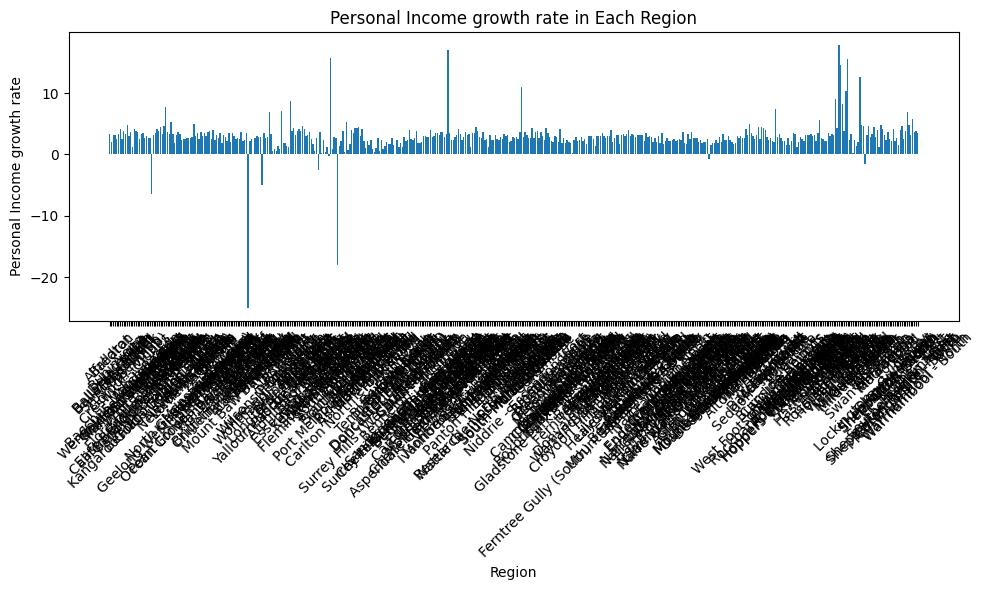

In [19]:
# bar plot to show the growth rate of each districts aunnal growth rate
plt.figure(figsize=(10, 6))
plt.bar(personal_income_final['SA2 NAME'], personal_income_final['average_annual_income_growth_rate(%)'])
plt.xlabel('Region')
plt.ylabel('Personal Income growth rate')
plt.title('Personal Income growth rate in Each Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# list the top 10 growth rate and plot the image 
top_10_personal_income_growth_rate= personal_income_final.sort_values(by='average_annual_income_growth_rate(%)',ascending=False).head(10)
top_10_personal_income_growth_rate

,SA2,SA2 NAME,2021-22,average_annual_income_growth_rate(%)
416,215011389,Horsham Region,89425.674593,17.753507
193,208031192,Moorabbin Airport,122769.079345,16.940346
126,206041127,West Melbourne,144036.553825,15.735652
421,215011394,Yarriambiack,88156.257585,15.551619
417,215011390,Nhill Region,83541.279950,14.649376
428,215031400,Buloke,68085.349653,12.617315
235,210011227,Essendon Airport,74211.991087,11.011808
420,215011393,West Wimmera,76329.541674,10.289605
414,215011387,Ararat Region,70748.665327,8.969365
103,205051104,Yarram,73823.981619,8.700927
